# 03 - Backlog Analysis｜積壓訂單分析

## 分析目的

本 Notebook 延續 `02_demand_shipment_analysis.ipynb`，檢查 New Orders 與 Shipments 的差距是否同步反映在 **Unfilled Orders（未完成訂單／Backlog）**。

主要回答四個 Planner 問題：

1. Backlog 目前是在增加還是減少？
2. 這個變化是單月波動，還是已持續一段時間？
3. Backlog 相對目前 Shipment run-rate 的規模有多大？
4. 02 的 Orders vs Shipments 訊號，和官方 Unfilled Orders 的變化是否一致？

## 主要指標

- **Unfilled Orders**：截至月底仍未完成的訂單存量。
- **Backlog Change**：本月 Unfilled Orders − 上月 Unfilled Orders。
- **Backlog YoY**：本月 Backlog 相對去年同月的百分比變化。
- **Backlog Coverage Proxy**：Unfilled Orders ÷ 最近 3 個月平均 Shipments。
- **Order Gap**：New Orders − Shipments，延續 Notebook 02 的結果。

> **重要限制：** Backlog Coverage Proxy 不是 Customer Lead Time。公開產業資料不包含產品組合、製程 routing、WIP、機台產能、客戶優先順序與承諾交期，因此 Coverage 只能用來比較 Backlog 相對 Shipment run-rate 的規模。


## Step 1｜載入分析套件

### 這一格要做什麼？

載入 03 所需的 Python 套件：

- `Path`：處理專案路徑。
- `numpy`：數值計算。
- `pandas`：處理 Backlog 與 Shipment 月資料。
- `matplotlib`：繪製趨勢圖。
- `display`：顯示 DataFrame。

### 為什麼要做？

03 不重新下載官方資料，而是直接接續 02 已建立的月度 KPI。這樣可以保持分析鏈一致：

`01 Data Validation → 02 Demand vs Shipment → 03 Backlog`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Libraries loaded successfully.")


Libraries loaded successfully.


### 輸出解讀

實際輸出：

```text
Libraries loaded successfully.
```

代表本 Notebook 使用的套件都成功載入，沒有發生 Import Error。

**白話解讀：** Python 分析環境正常，可以進入資料讀取與 Backlog 分析。

**下一步：**讀取 02 已保存的月度 Demand / Shipment 分析結果。


## Step 2｜讀取 02 的 Demand / Shipment 月度結果

### 這一格要做什麼？

讀取：

`reports/tables/demand_shipment_monthly_metrics.csv`

這份資料除了原始欄位，也包含 02 已計算完成的：

- `order_gap`
- `book_to_bill`
- `book_to_bill_3m`
- MoM / YoY
- rolling metrics

### 為什麼不重新從 01 計算？

每一本 Notebook 都使用前一階段已驗證與保存的輸出，可以減少重複計算，也讓資料處理流程更容易追蹤。


In [2]:
PROJECT_ROOT = Path.cwd().parent

INPUT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "demand_shipment_monthly_metrics.csv"
)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"02 output not found: {INPUT_PATH}\n"
        "Please run 02_demand_shipment_analysis.ipynb first."
    )

backlog_data = pd.read_csv(
    INPUT_PATH,
    parse_dates=["date"],
)

backlog_data = (
    backlog_data
    .sort_values("date")
    .reset_index(drop=True)
)

print("Loaded:", INPUT_PATH)
print("Shape:", backlog_data.shape)

display(backlog_data.head())
display(backlog_data.tail())


Loaded: C:\Users\momo8\Desktop\electronic-components-planning\reports\tables\demand_shipment_monthly_metrics.csv
Shape: (415, 19)


,date,new_orders,shipments,unfilled_orders,inventories,industrial_production,order_gap,book_to_bill,new_orders_mom_pct,shipments_mom_pct,new_orders_yoy_pct,shipments_yoy_pct,new_orders_3m_avg,shipments_3m_avg,order_gap_3m_avg,book_to_bill_3m,orders_12m_sum,shipments_12m_sum,book_to_bill_12m
0,1992-02-01,3411,3484,8656,7714,0.3629,-73,0.979047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1992-03-01,3711,3754,8613,7661,0.3675,-43,0.988546,8.795075,7.749713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1992-04-01,3745,3652,8706,7520,0.3725,93,1.025465,0.916195,-2.717102,NaN,NaN,3622.333333,3630.000000,-7.666667,0.997888,NaN,NaN,NaN
3,1992-05-01,3735,3673,8768,7427,0.3777,62,1.016880,-0.267023,0.575027,NaN,NaN,3730.333333,3693.000000,37.333333,1.010109,NaN,NaN,NaN
4,1992-06-01,3814,3701,8881,7585,0.3903,113,1.030532,2.115127,0.762320,NaN,NaN,3764.666667,3675.333333,89.333333,1.024306,NaN,NaN,NaN


,date,new_orders,shipments,unfilled_orders,inventories,industrial_production,order_gap,book_to_bill,new_orders_mom_pct,shipments_mom_pct,new_orders_yoy_pct,shipments_yoy_pct,new_orders_3m_avg,shipments_3m_avg,order_gap_3m_avg,book_to_bill_3m,orders_12m_sum,shipments_12m_sum,book_to_bill_12m
410,2026-04-01,5405,5319,18494,13382,176.6948,86,1.016168,-0.018498,0.700492,8.577742,5.118577,5386.333333,5301.000000,85.333333,1.016098,63218.0,62787.0,1.006864
411,2026-05-01,5579,5438,18635,13473,184.1891,141,1.025929,3.219241,2.237263,8.372183,7.619236,5463.333333,5346.333333,117.000000,1.021884,63649.0,63172.0,1.007551
412,2026-06-01,5668,5567,18736,13989,187.5187,101,1.018143,1.595268,2.372196,9.167951,7.098884,5550.666667,5441.333333,109.333333,1.020093,64125.0,63541.0,1.009191
413,2026-07-01,5711,5570,18877,14001,190.2607,141,1.025314,0.758645,0.053889,9.784698,7.321773,5652.666667,5525.000000,127.666667,1.023107,64634.0,63921.0,1.011154
414,2026-08-01,5769,5625,19021,14129,190.0987,144,1.025600,1.015584,0.987433,11.845677,8.506944,5716.000000,5587.333333,128.666667,1.023028,65245.0,64362.0,1.013719


### 輸出解讀

實際讀取結果：

```text
Shape: (415, 19)
```

資料期間為 **1992-02 到 2026-08**，共有 415 個月份與 19 個欄位。

最新月份 2026-08 顯示：

- New Orders = **5,769 百萬美元**
- Shipments = **5,625 百萬美元**
- Unfilled Orders = **19,021 百萬美元**
- Order Gap = **+144 百萬美元**
- 3M Book-to-Bill = **1.023**
- 12M Book-to-Bill = **1.014**

**白話解讀：** 03 已正確接上 02 的輸出，且最新月份與 02 的結果一致。Backlog 欄位也已包含在同一張月度資料中，可以直接往下分析。

**下一步：**先確認 Backlog 與 Shipment 欄位沒有缺值、負數或其他會影響 Coverage 計算的問題。


## Step 3｜Backlog 分析前安全檢查

### 這一格要做什麼？

確認以下條件：

- `unfilled_orders`、`shipments`、`order_gap`、`book_to_bill_3m` 等必要欄位存在。
- 日期沒有重複。
- Backlog 沒有空值。
- Backlog 沒有負值。
- Shipments 全部大於 0。

### 為什麼 Shipments 必須大於 0？

後面會計算：

`Backlog Coverage Proxy = Unfilled Orders / 3-Month Average Shipments`

如果 Shipment 為 0，Coverage 會無法正常解讀。


In [3]:
required_columns = {
    "date",
    "new_orders",
    "shipments",
    "unfilled_orders",
    "order_gap",
    "book_to_bill",
    "book_to_bill_3m",
}

missing_columns = required_columns - set(backlog_data.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

if backlog_data["date"].duplicated().any():
    raise ValueError("Duplicate monthly dates were found.")

if backlog_data["unfilled_orders"].isna().any():
    raise ValueError("Unfilled Orders contains missing values.")

if (backlog_data["unfilled_orders"] < 0).any():
    raise ValueError("Unfilled Orders contains negative values.")

if (backlog_data["shipments"] <= 0).any():
    raise ValueError(
        "Shipments must be greater than zero for backlog coverage analysis."
    )

print("BACKLOG INPUT CHECK: PASS")
print(
    "Date range:",
    backlog_data["date"].min().date(),
    "to",
    backlog_data["date"].max().date(),
)
print("Rows:", len(backlog_data))


BACKLOG INPUT CHECK: PASS
Date range: 1992-02-01 to 2026-08-01
Rows: 415


### 輸出解讀

實際輸出：

```text
BACKLOG INPUT CHECK: PASS
Date range: 1992-02-01 to 2026-08-01
Rows: 415
```

代表：

- 必要欄位都存在。
- 日期沒有重複。
- Backlog 沒有缺值或負值。
- Shipments 沒有 0 或負值。

**白話解讀：** 目前資料可以安全進行 Backlog Change、YoY 與 Coverage 計算，沒有明顯的資料品質問題會干擾後續結果。

**下一步：**建立 Backlog 自身的變化指標。


## Step 4｜建立 Backlog KPI

### 這一格要做什麼？

建立六類 Backlog 指標：

### 1. Monthly Backlog Change
`本月 Unfilled Orders − 上月 Unfilled Orders`

- 正值：月底 Backlog 增加。
- 負值：月底 Backlog 減少。

### 2. Backlog MoM %
比較本月與上月 Backlog 的百分比變化。

### 3. Backlog YoY %
比較本月與去年同月 Backlog 的百分比變化。

### 4. 3-Month Backlog Change
`本月 Backlog − 3 個月前 Backlog`

用來觀察短期累積方向。

### 5. 12-Month Backlog Change
`本月 Backlog − 12 個月前 Backlog`

用來觀察較長期變化。

### 6. 3-Month Average Shipments
使用最近 3 個月平均 Shipment 作為較穩定的出貨 run-rate，供後續 Coverage 計算使用。


In [4]:
analysis_data = backlog_data.copy()

analysis_data["backlog_change"] = (
    analysis_data["unfilled_orders"].diff()
)

analysis_data["backlog_mom_pct"] = (
    analysis_data["unfilled_orders"]
    .pct_change(fill_method=None)
    * 100
)

analysis_data["backlog_yoy_pct"] = (
    analysis_data["unfilled_orders"]
    .pct_change(periods=12, fill_method=None)
    * 100
)

analysis_data["backlog_change_3m"] = (
    analysis_data["unfilled_orders"]
    - analysis_data["unfilled_orders"].shift(3)
)

analysis_data["backlog_change_12m"] = (
    analysis_data["unfilled_orders"]
    - analysis_data["unfilled_orders"].shift(12)
)

analysis_data["backlog_3m_avg"] = (
    analysis_data["unfilled_orders"]
    .rolling(window=3)
    .mean()
)

analysis_data["shipments_3m_avg"] = (
    analysis_data["shipments"]
    .rolling(window=3)
    .mean()
)

print("Backlog KPIs created successfully.")

display(
    analysis_data[
        [
            "date",
            "unfilled_orders",
            "backlog_change",
            "backlog_mom_pct",
            "backlog_yoy_pct",
            "backlog_change_3m",
            "backlog_change_12m",
        ]
    ].tail(12)
)


Backlog KPIs created successfully.


,date,unfilled_orders,backlog_change,backlog_mom_pct,backlog_yoy_pct,backlog_change_3m,backlog_change_12m
403,2025-09-01,18096,-42.0,-0.231558,-2.157340,-56.0,-399.0
404,2025-10-01,18153,57.0,0.314987,-1.508328,-11.0,-278.0
405,2025-11-01,18188,35.0,0.192806,-1.200500,50.0,-221.0
406,2025-12-01,18166,-22.0,-0.120959,-0.937943,70.0,-172.0
407,2026-01-01,18238,72.0,0.396345,-0.016446,85.0,-3.0
408,2026-02-01,18284,46.0,0.252221,0.921786,96.0,167.0
409,2026-03-01,18408,124.0,0.678189,1.449435,242.0,263.0
410,2026-04-01,18494,86.0,0.467188,2.386093,256.0,431.0
411,2026-05-01,18635,141.0,0.762409,2.626941,351.0,477.0
412,2026-06-01,18736,101.0,0.541991,3.217276,328.0,584.0


### 輸出解讀

Backlog KPI 已成功建立。

最近 12 個月最明顯的變化如下：

- 2025-09 Backlog = **18,096**，當月減少 **42 百萬美元**。
- 2025-12 Backlog = **18,166**，當月減少 **22 百萬美元**。
- 2026-01 起 Backlog 連續增加。
- 2026-08 Backlog = **19,021 百萬美元**。
- 2026-08 單月增加 **144 百萬美元**。
- 最近 3 個月淨增加 **386 百萬美元**。
- 最近 12 個月淨增加 **883 百萬美元**。
- Backlog YoY = **+4.87%**。

Backlog YoY 在 2025 年底仍為負值，2026-02 轉為正值，之後一路上升至 2026-08 的 +4.87%。

**白話解讀：** Backlog 在 2025 年下半年仍偏平或下降，但 2026 年開始出現明顯反轉，且 2026-01 至 2026-08 持續累積。這表示目前的 Backlog 上升不是單一月份跳高。

**下一步：**把最近 12 個月的 Backlog 與 3M Book-to-Bill 放在同一張表中，確認近期 Orders / Shipments 與 Backlog 的方向是否同步。


## Step 5｜查看最近 12 個月 Backlog

### 這一格要做什麼？

把最近 12 個月的以下指標放在同一張表：

- Unfilled Orders
- Monthly Backlog Change
- Backlog YoY
- 3M Backlog Change
- 12M Backlog Change
- 3M Book-to-Bill

### 為什麼加入 3M Book-to-Bill？

02 已經顯示近期 New Orders 稍高於 Shipments。這一格用來檢查同一期間 Backlog 是否也同步往上。

此比較屬於描述性分析，不代表因果關係。


In [5]:
recent_12m = analysis_data.tail(12).copy()

recent_12m_display = recent_12m[
    [
        "date",
        "unfilled_orders",
        "backlog_change",
        "backlog_yoy_pct",
        "backlog_change_3m",
        "backlog_change_12m",
        "book_to_bill_3m",
    ]
].copy()

for column in [
    "backlog_yoy_pct",
    "book_to_bill_3m",
]:
    recent_12m_display[column] = (
        recent_12m_display[column].round(2)
    )

display(recent_12m_display)

latest = analysis_data.iloc[-1]

print()
print("LATEST BACKLOG SUMMARY")
print("-" * 60)
print("Date:", latest["date"].strftime("%Y-%m"))
print(
    f"Unfilled Orders: {latest['unfilled_orders']:,.0f} million USD"
)
print(
    f"Monthly Backlog Change: {latest['backlog_change']:,.0f} million USD"
)
print(
    f"Backlog YoY: {latest['backlog_yoy_pct']:.2f}%"
)
print(
    f"3-Month Backlog Change: {latest['backlog_change_3m']:,.0f} million USD"
)
print(
    f"12-Month Backlog Change: {latest['backlog_change_12m']:,.0f} million USD"
)
print(
    f"3-Month Book-to-Bill: {latest['book_to_bill_3m']:.3f}"
)


,date,unfilled_orders,backlog_change,backlog_yoy_pct,backlog_change_3m,backlog_change_12m,book_to_bill_3m
403,2025-09-01,18096,-42.0,-2.16,-56.0,-399.0,1.00
404,2025-10-01,18153,57.0,-1.51,-11.0,-278.0,1.00
405,2025-11-01,18188,35.0,-1.20,50.0,-221.0,1.00
406,2025-12-01,18166,-22.0,-0.94,70.0,-172.0,1.00
407,2026-01-01,18238,72.0,-0.02,85.0,-3.0,1.01
408,2026-02-01,18284,46.0,0.92,96.0,167.0,1.01
409,2026-03-01,18408,124.0,1.45,242.0,263.0,1.02
410,2026-04-01,18494,86.0,2.39,256.0,431.0,1.02
411,2026-05-01,18635,141.0,2.63,351.0,477.0,1.02
412,2026-06-01,18736,101.0,3.22,328.0,584.0,1.02



LATEST BACKLOG SUMMARY
------------------------------------------------------------
Date: 2026-08
Unfilled Orders: 19,021 million USD
Monthly Backlog Change: 144 million USD
Backlog YoY: 4.87%
3-Month Backlog Change: 386 million USD
12-Month Backlog Change: 883 million USD
3-Month Book-to-Bill: 1.023


### 輸出解讀

最新月份 **2026-08**：

```text
Unfilled Orders: 19,021 million USD
Monthly Backlog Change: +144 million USD
Backlog YoY: +4.87%
3-Month Backlog Change: +386 million USD
12-Month Backlog Change: +883 million USD
3-Month Book-to-Bill: 1.023
```

最近 12 個月的變化也顯示：

- 2025-09、2025-12 的 Backlog 有小幅下降。
- 2026-01 至 2026-08 每個月 Backlog 都增加。
- Backlog YoY 從 2025-09 的 **-2.16%**，逐步轉為 2026-08 的 **+4.87%**。
- 3M Book-to-Bill 在 2026 年維持約 **1.01～1.02**。

**白話解讀：** 近期 New Orders 稍高於 Shipments 的同時，官方 Unfilled Orders 也持續增加。2026-08 的 Backlog 不只高於 3 個月前，也比一年前高 883 百萬美元。

但這仍屬於產業層級的 Backlog 變化，無法直接推論單一客戶訂單一定延遲。

**下一步：**把最新 Backlog 放回完整歷史中，判斷目前是歷史高位、一般區間，還是近期重新上升。


## Step 6｜查看完整歷史 Backlog

### 這一格要做什麼？

繪製 1992 至 2026-08 的 Unfilled Orders 長期趨勢。

### 分析重點

- Backlog 是否存在長期結構性變化。
- 歷史上曾出現哪些明顯高點與低點。
- 目前的 Backlog 相對歷史處於什麼位置。

### 為什麼不能只看最新值？

Backlog 金額會受到產業規模長期變化影響，因此「數字很高」本身不足以代表當期履約壓力突然惡化。


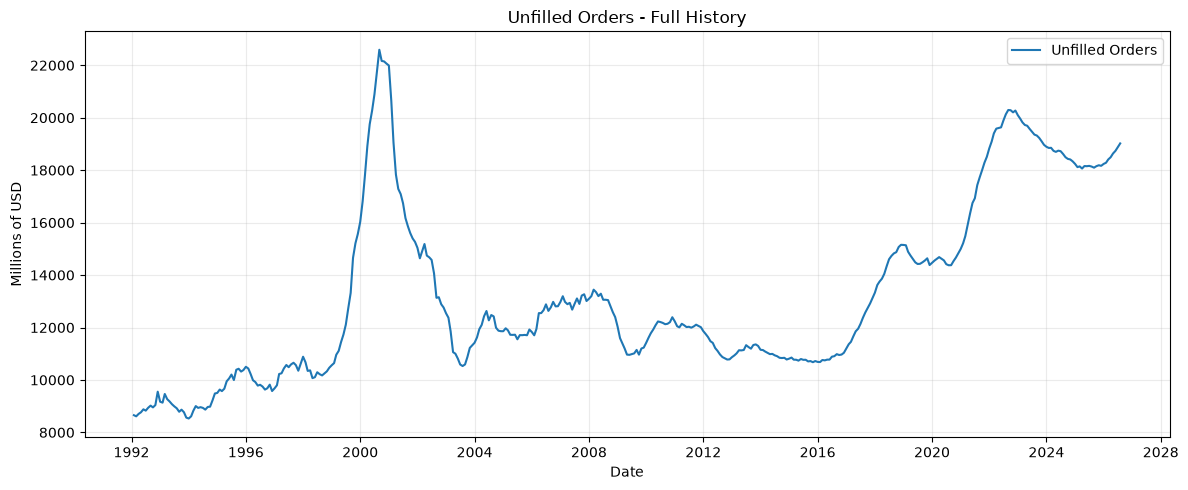

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\03_unfilled_orders_full_history.png


In [6]:
REPORT_FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    analysis_data["date"],
    analysis_data["unfilled_orders"],
    label="Unfilled Orders",
)

ax.set_title("Unfilled Orders - Full History")
ax.set_xlabel("Date")
ax.set_ylabel("Millions of USD")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "03_unfilled_orders_full_history.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

完整歷史圖顯示 Backlog 的長期波動非常明顯。

主要特徵：

- 1990 年代 Backlog 大致從 8,000～10,000 百萬美元附近逐步上升。
- 2000 年前後出現歷史上非常明顯的高峰，超過 **22,000 百萬美元**。
- 2001～2004 隨後快速下降。
- 2004～2016 多數時間約落在 10,000～13,000 百萬美元區間。
- 2017 之後再次明顯上升。
- 2022 左右升到約 **20,000 百萬美元以上**，之後回落。
- 2026-08 回升至 **19,021 百萬美元**。

**白話解讀：** 2026-08 的 Backlog 處於長期相對高位，但仍低於 2000 年前後的歷史極端高點，也低於 2022 左右的近期高峰。因此不能單純以「19,021 很高」判定風險；近期的變化方向更值得關注。

**下一步：**縮小到最近 5 年，觀察 2022 高點之後的下降，以及 2026 是否已出現新的轉折。


## Step 7｜查看最近 5 年 Backlog 趨勢

### 這一格要做什麼？

顯示最近 60 個月：

- Monthly Unfilled Orders
- 3-Month Average Backlog

### 為什麼加入 3M Average？

3 個月平均可以降低單月小幅波動，讓短期 Backlog 的方向轉折更容易辨識。


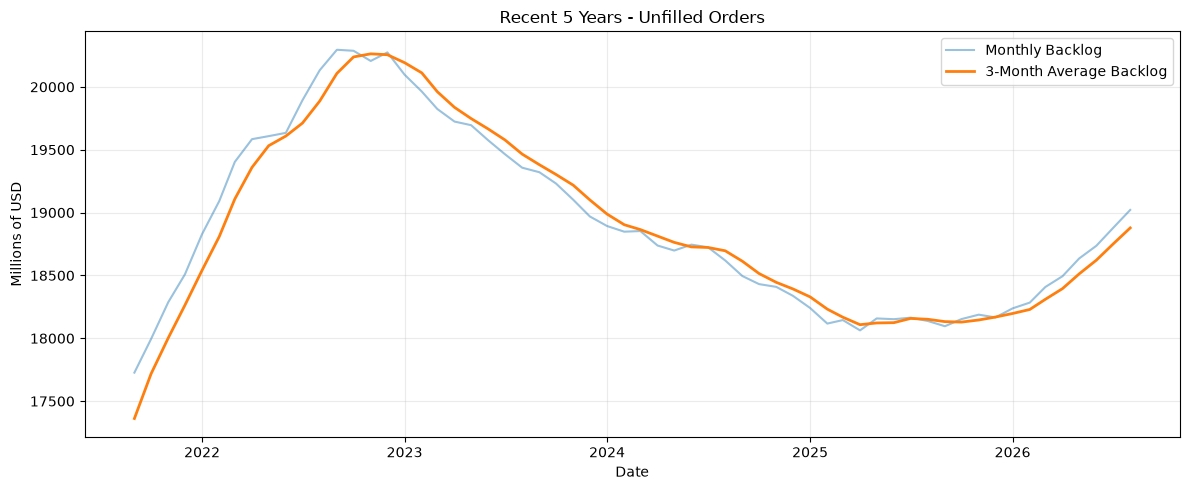

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\03_unfilled_orders_recent_5y.png


In [7]:
recent_5y = analysis_data.tail(60).copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    recent_5y["date"],
    recent_5y["unfilled_orders"],
    alpha=0.45,
    label="Monthly Backlog",
)

ax.plot(
    recent_5y["date"],
    recent_5y["backlog_3m_avg"],
    linewidth=2,
    label="3-Month Average Backlog",
)

ax.set_title("Recent 5 Years - Unfilled Orders")
ax.set_xlabel("Date")
ax.set_ylabel("Millions of USD")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "03_unfilled_orders_recent_5y.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

最近 5 年圖表顯示：

- 2021 下半年到 2022 年，Backlog 快速上升。
- 2022 年底附近達到約 **20,300 百萬美元**的近期高位。
- 2023～2025 年初整體持續下降。
- 2025 年中附近 Backlog 約降到 **18,100 百萬美元**左右。
- 2025 下半年開始逐漸轉為平穩。
- 2026 年明顯重新上升，最新到 **19,021 百萬美元**。
- 3-Month Average 也已轉為上升，而不是只有單月值跳高。

**白話解讀：** 最近 5 年呈現「2022 高點 → 2023～2025 消化 → 2026 再度累積」的結構。2026 的上升屬於趨勢轉折，而不是單月雜訊。

**下一步：**直接查看每月 Backlog 增減量，確認最近一年有多少月份真的在累積。


## Step 8｜分析每月 Backlog Change

### 這一格要做什麼？

計算並繪製：

`本月 Backlog − 上月 Backlog`

### 判讀方式

- `> 0`：當月 Backlog 增加。
- `< 0`：當月 Backlog 減少。
- 接近 0：月底 Backlog 大致穩定。

另外統計最近 12 個月中 Backlog 增加與減少的月份數。

### 為什麼要看變化量？

Backlog 水準回答「現在有多少」，Backlog Change 回答「壓力是在增加還是在被消化」。


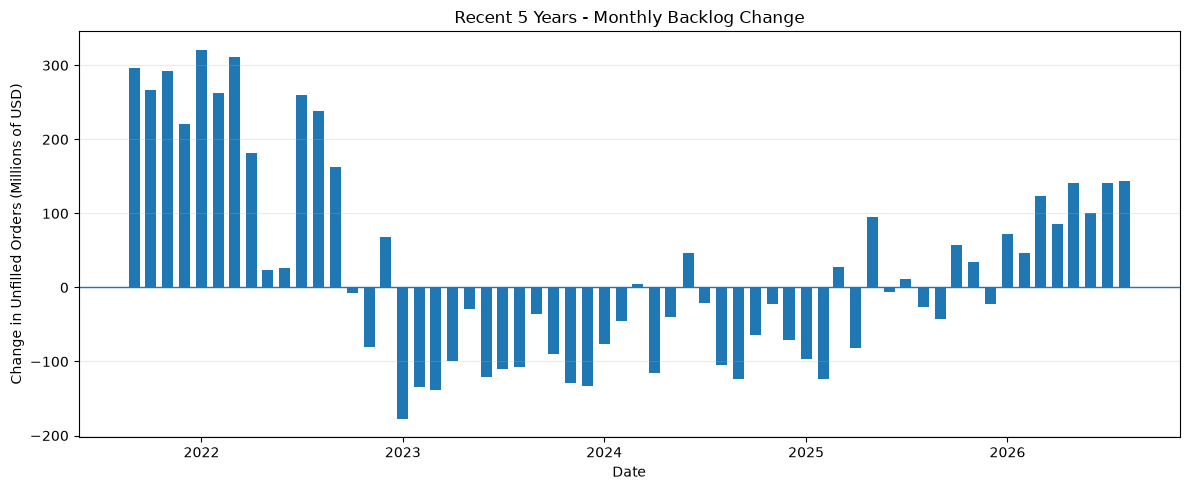

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\03_backlog_change_recent_5y.png

In the latest 12 months: 10 months had backlog increases, 2 months had backlog decreases.


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    recent_5y["date"],
    recent_5y["backlog_change"],
    width=20,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title("Recent 5 Years - Monthly Backlog Change")
ax.set_xlabel("Date")
ax.set_ylabel("Change in Unfilled Orders (Millions of USD)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "03_backlog_change_recent_5y.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

recent_12m_backlog_up = int(
    (recent_12m["backlog_change"] > 0).sum()
)

recent_12m_backlog_down = int(
    (recent_12m["backlog_change"] < 0).sum()
)

print()
print(
    f"In the latest 12 months: "
    f"{recent_12m_backlog_up} months had backlog increases, "
    f"{recent_12m_backlog_down} months had backlog decreases."
)


### 輸出解讀

最近 5 年的 Monthly Backlog Change 圖顯示：

- 2021～2022 有多個月份出現明顯正值，對應 Backlog 快速累積。
- 2023～2024 多數月份轉為負值，代表 Backlog 在被消化。
- 2025 正負交錯，變化幅度較小。
- 2026 年的柱狀值全部位於 0 上方，且近期多次超過 +100 百萬美元。

最近 12 個月統計：

```text
10 months had backlog increases
2 months had backlog decreases
```

也就是 **10 / 12 個月（約 83%）** Backlog 增加。

**白話解讀：** 最近一年 Backlog 增加的月份明顯多於下降月份，尤其 2026 年的月度變化持續為正，支持「近期 Backlog 正在重新累積」的判讀。

**下一步：**比較 `Order Gap` 與官方 `Backlog Change`，確認兩者在這份資料中的實際關係。


## Step 9｜比較 Order Gap 與 Backlog Change

### 這一格要做什麼？

比較：

- `Order Gap = New Orders − Shipments`
- `Backlog Change = 本月 Unfilled Orders − 上月 Unfilled Orders`

另外計算：

`Backlog Adjustment Residual = Backlog Change − Order Gap`

以及兩者的歷史 correlation。

### 為什麼需要這一步？

在分析設計上，不能預先假設 `New Orders − Shipments` 一定等於官方 Backlog Change。實際輸出可以用來判斷兩者在這份 M3 資料中的關係到底有多接近。

> 若 Residual 持續接近 0，代表兩者在這份資料中存在非常強的會計式連動，後續就不應把它們視為兩個獨立的壓力證據。


In [9]:
analysis_data["backlog_adjustment_residual"] = (
    analysis_data["backlog_change"]
    - analysis_data["order_gap"]
)

recent_24m = analysis_data.tail(24).copy()

comparison_table = recent_24m[
    [
        "date",
        "order_gap",
        "backlog_change",
        "backlog_adjustment_residual",
    ]
].copy()

display(comparison_table)

valid_comparison = analysis_data[
    ["order_gap", "backlog_change"]
].dropna()

correlation = valid_comparison["order_gap"].corr(
    valid_comparison["backlog_change"]
)

print()
print(
    f"Historical correlation between Order Gap and Backlog Change: "
    f"{correlation:.3f}"
)


,date,order_gap,backlog_change,backlog_adjustment_residual
391,2024-09-01,-124,-124.0,0.0
392,2024-10-01,-64,-64.0,0.0
393,2024-11-01,-22,-22.0,0.0
394,2024-12-01,-71,-71.0,0.0
395,2025-01-01,-97,-97.0,0.0
396,2025-02-01,-124,-124.0,0.0
397,2025-03-01,28,28.0,0.0
398,2025-04-01,-82,-82.0,0.0
399,2025-05-01,95,95.0,0.0
400,2025-06-01,-6,-6.0,0.0



Historical correlation between Order Gap and Backlog Change: 1.000


### 輸出解讀

最近 24 個月的實際結果顯示：

- 每一個月份的 `Order Gap`
- 都和同月 `Backlog Change`
- **完全相同**
- `backlog_adjustment_residual` 全部為 **0**

例如：

| 月份 | Order Gap | Backlog Change | Residual |
|---|---:|---:|---:|
| 2026-05 | +141 | +141 | 0 |
| 2026-06 | +101 | +101 | 0 |
| 2026-07 | +141 | +141 | 0 |
| 2026-08 | +144 | +144 | 0 |

歷史 correlation 輸出：

```text
1.000
```

**白話解讀：** 在目前顯示的最近 24 個月中，官方 Backlog 的月變化和 `New Orders − Shipments` 完全一致；全歷史 correlation 也四捨五入為 1.000。

因此這兩個指標在這份資料中**不能當成兩份獨立證據重複計算**。Backlog Change 基本上是在呈現與 Order Gap 相同的月度流量關係。

### 嚴格限制

目前 Code 只顯示最近 24 個月的 Residual，雖然全歷史 correlation 為 1.000，但如果要證明「整個 415 個月 Residual 都完全等於 0」，仍應另外檢查：

`analysis_data["backlog_adjustment_residual"].abs().max()`

在沒有這個額外輸出前，最安全的描述是：

> 最近 24 個月完全一致，且全歷史呈現近乎完全的一致關係。

**下一步：**改用 Backlog Coverage Proxy，加入相對 Shipment run-rate 的觀點，避免只重複同一個 Orders-vs-Shipments 關係。


## Step 10｜建立 Backlog Coverage Proxy

### 公式

`Backlog Coverage Proxy = Unfilled Orders / 3-Month Average Shipments`

### 白話概念

若：

- Backlog = 18,000
- 最近 3 個月平均 Shipments = 6,000 / month

則：

`18,000 / 6,000 = 3.0 months`

代表 Backlog 金額規模大約相當於 **3 個月近期平均 Shipment run-rate**。

### 為什麼叫 Proxy？

這不是實際 Customer Lead Time，因為缺少：

- 產品組合
- 製程 cycle time
- routing
- WIP
- machine capacity
- yield
- customer priority

因此 Coverage 只能作為「Backlog 相對 Shipment 規模」的比較指標。


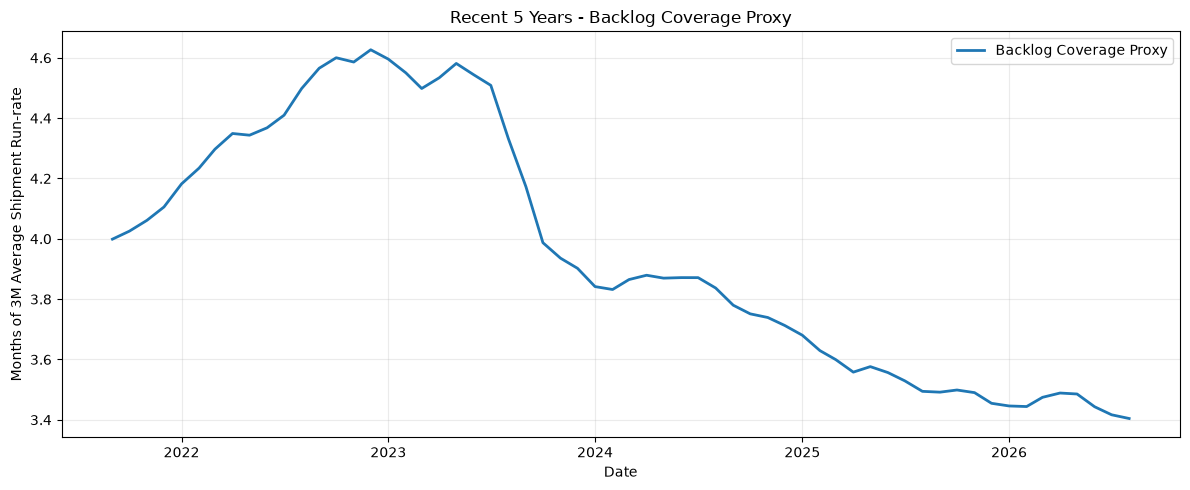

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\03_backlog_coverage_recent_5y.png

Latest Backlog Coverage Proxy: 3.40 months
3-Month Coverage Change: -0.08 months


In [10]:
analysis_data["backlog_coverage_months"] = (
    analysis_data["unfilled_orders"]
    / analysis_data["shipments_3m_avg"]
)

analysis_data["backlog_coverage_change_3m"] = (
    analysis_data["backlog_coverage_months"]
    - analysis_data["backlog_coverage_months"].shift(3)
)

recent_5y = analysis_data.tail(60).copy()
latest = analysis_data.iloc[-1]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    recent_5y["date"],
    recent_5y["backlog_coverage_months"],
    linewidth=2,
    label="Backlog Coverage Proxy",
)

ax.set_title(
    "Recent 5 Years - Backlog Coverage Proxy"
)
ax.set_xlabel("Date")
ax.set_ylabel("Months of 3M Average Shipment Run-rate")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "03_backlog_coverage_recent_5y.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

print()
print(
    f"Latest Backlog Coverage Proxy: "
    f"{latest['backlog_coverage_months']:.2f} months"
)
print(
    f"3-Month Coverage Change: "
    f"{latest['backlog_coverage_change_3m']:.2f} months"
)


### 輸出解讀

最新輸出：

```text
Latest Backlog Coverage Proxy: 3.40 months
3-Month Coverage Change: -0.08 months
```

圖表顯示最近 5 年 Coverage 大致：

- 2021 約 **4.0 個月**
- 2022～2023 初一度升到約 **4.6 個月**
- 之後持續下降
- 2025 約降到 3.5 個月附近
- 2026-08 最新為 **3.40 個月**

**白話解讀：**

2026-08 的 Backlog 雖然已增加到 19,021 百萬美元，但相對最近 3 個月的 Shipment run-rate，Coverage 反而比 3 個月前下降 **0.08 個月**。

這表示：

> Backlog 的絕對金額正在增加，但 Shipments 的近期規模也在增加，而且增長速度足以讓「Backlog ÷ Shipment run-rate」沒有惡化。

因此不能只因 Backlog 增加就直接判定履約壓力全面變差。

另外，**3.40 months 不能解讀成客戶平均交期 3.40 個月**；正確意思只是 Backlog 金額約等於 3.40 個月近期平均 Shipment 規模。

**下一步：**把 demand flow、Backlog 水準與 Coverage 放在同一張 evidence table 中，呈現目前訊號是「部分偏緊、部分改善」。


## Step 11｜整合 Demand Pressure 與 Backlog Pressure

### 這一格要做什麼？

整理以下指標：

- 3M Book-to-Bill
- 12M Book-to-Bill
- 3M Backlog Change
- 12M Backlog Change
- Backlog YoY
- Backlog Coverage
- 3M Coverage Change

### 為什麼不建立 0–100 的 AI Risk Score？

公開資料沒有真正的：

- capacity constraint
- promised delivery date
- customer order priority
- WIP
- product mix

因此沒有可靠的 delivery-delay label 可以支撐風險機率模型。使用透明的 Evidence Table，比建立無法驗證的 AI Risk Score 更符合資料可支持的範圍。

### 另外需要注意

`Backlog Change` 與 `Order Gap` 在上一格呈現近乎完全一致，因此不同 signal 並不一定彼此獨立，不能單純把「幾個 YES」當成統計機率。


In [11]:
analysis_data["orders_12m_sum"] = (
    analysis_data["new_orders"]
    .rolling(window=12)
    .sum()
)

analysis_data["shipments_12m_sum"] = (
    analysis_data["shipments"]
    .rolling(window=12)
    .sum()
)

analysis_data["book_to_bill_12m"] = (
    analysis_data["orders_12m_sum"]
    / analysis_data["shipments_12m_sum"]
)

latest = analysis_data.iloc[-1]

evidence_table = pd.DataFrame(
    {
        "signal": [
            "3M Book-to-Bill",
            "12M Book-to-Bill",
            "3M Backlog Change (USD mn)",
            "12M Backlog Change (USD mn)",
            "Backlog YoY",
            "Backlog Coverage Proxy (months)",
            "3M Coverage Change (months)",
        ],
        "value": [
            round(float(latest["book_to_bill_3m"]), 3),
            round(float(latest["book_to_bill_12m"]), 3),
            round(float(latest["backlog_change_3m"]), 2),
            round(float(latest["backlog_change_12m"]), 2),
            f"{latest['backlog_yoy_pct']:.2f}%",
            round(float(latest["backlog_coverage_months"]), 2),
            round(float(latest["backlog_coverage_change_3m"]), 2),
        ],
    }
)

display(evidence_table)

print()
print("PLANNER EVIDENCE READ")
print("-" * 60)

if latest["book_to_bill_3m"] > 1:
    print(
        "1. Recent incoming orders are running above recent shipments."
    )
else:
    print(
        "1. Recent shipments are running at or above incoming orders."
    )

if latest["backlog_change_3m"] > 0:
    print(
        "2. Backlog has increased over the latest 3-month window."
    )
else:
    print(
        "2. Backlog has not increased over the latest 3-month window."
    )

if latest["backlog_yoy_pct"] > 0:
    print(
        "3. Backlog is higher than the same month one year ago."
    )
else:
    print(
        "3. Backlog is not higher than the same month one year ago."
    )

if latest["backlog_coverage_change_3m"] > 0:
    print(
        "4. Backlog coverage has increased relative to the recent shipment run-rate."
    )
else:
    print(
        "4. Backlog coverage has not increased relative to the recent shipment run-rate."
    )


,signal,value
0,3M Book-to-Bill,1.023
1,12M Book-to-Bill,1.014
2,3M Backlog Change (USD mn),386.0
3,12M Backlog Change (USD mn),883.0
4,Backlog YoY,4.87%
5,Backlog Coverage Proxy (months),3.4
6,3M Coverage Change (months),-0.08



PLANNER EVIDENCE READ
------------------------------------------------------------
1. Recent incoming orders are running above recent shipments.
2. Backlog has increased over the latest 3-month window.
3. Backlog is higher than the same month one year ago.
4. Backlog coverage has not increased relative to the recent shipment run-rate.


### 輸出解讀

Evidence Table 實際結果：

| Signal | 最新值 |
|---|---:|
| 3M Book-to-Bill | **1.023** |
| 12M Book-to-Bill | **1.014** |
| 3M Backlog Change | **+386 百萬美元** |
| 12M Backlog Change | **+883 百萬美元** |
| Backlog YoY | **+4.87%** |
| Backlog Coverage Proxy | **3.40 months** |
| 3M Coverage Change | **-0.08 months** |

輸出判讀為：

1. Recent Orders > Shipments：**YES**
2. 3M Backlog Increasing：**YES**
3. Backlog Higher YoY：**YES**
4. Backlog Coverage Increasing：**NO**

### 白話解讀

目前訊號並不是「全面惡化」。

支持壓力增加的證據：

- 近期 Orders 高於 Shipments。
- Backlog 最近 3 個月增加 386 百萬美元。
- Backlog 比去年同月高 4.87%。

但同時：

- Coverage 比 3 個月前下降 0.08 個月。

這表示 Backlog 金額雖然上升，但近期 Shipment run-rate 也在增強，因此相對 Coverage 並沒有同步惡化。

### 嚴格解讀

`3M Book-to-Bill > 1` 與 `3M Backlog Change > 0` 並非完全獨立的證據，因為上一格已顯示 Order Gap 與 Backlog Change 高度一致。因此「3/4 signals positive」只能當作簡單整理，**不能解讀成 75% 風險、75% 機率或三份獨立證據**。

目前較合理的結論是：

> 近期 demand / backlog 的絕對值方向偏緊，但相對 Shipment run-rate 的 Backlog Coverage 仍在改善，因此履約壓力訊號屬於混合狀態。

**下一步：**用年度 Stock / Flow 正確方法整理 Backlog 長期變化。


## Step 12｜建立年度 Backlog Summary

### 這一格要做什麼？

建立每個完整年度的：

- 年底 Backlog
- 年平均 Backlog
- 年平均 Shipments
- 年底 Backlog Coverage

### 為什麼使用「年底 Backlog」而不是把 12 個月 Backlog 加總？

Unfilled Orders 是 **Stock（存量）**。

例如：

- 1 月 Backlog = 100
- 2 月 Backlog = 110

不能把它解讀成兩個月 Backlog = 210，因為同一批未完成訂單可能持續存在於兩個月。

因此：

- Orders / Shipments 是期間流量，可以加總。
- Backlog / Inventory 是時間點存量，通常使用期末值或平均值。


In [12]:
yearly_backlog_summary = (
    analysis_data
    .assign(year=analysis_data["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        month_count=("date", "count"),
        year_end_backlog=("unfilled_orders", "last"),
        average_backlog=("unfilled_orders", "mean"),
        average_shipments=("shipments", "mean"),
        year_end_coverage=(
            "backlog_coverage_months",
            "last",
        ),
    )
)

yearly_backlog_summary = yearly_backlog_summary.loc[
    yearly_backlog_summary["month_count"].eq(12)
].copy()

display(
    yearly_backlog_summary.tail(10).round(
        {
            "average_backlog": 2,
            "average_shipments": 2,
            "year_end_coverage": 2,
        }
    )
)


,year,month_count,year_end_backlog,average_backlog,average_shipments,year_end_coverage
24,2016,12,11036,10847.17,3389.17,3.27
25,2017,12,13120,12113.33,3626.08,3.36
26,2018,12,15154,14350.75,4040.75,3.63
27,2019,12,14382,14661.17,4146.17,3.56
28,2020,12,14827,14557.50,4024.83,3.57
29,2021,12,18508,16798.83,4374.92,4.11
30,2022,12,20274,19769.83,4459.42,4.63
31,2023,12,18969,19526.75,4551.58,3.90
32,2024,12,18338,18649.25,4888.08,3.71
33,2025,12,18166,18148.42,5146.42,3.45


### 輸出解讀

最近 10 個完整年度顯示：

| 年份 | 年底 Backlog | 年底 Coverage |
|---|---:|---:|
| 2016 | 11,036 | 3.27 |
| 2017 | 13,120 | 3.36 |
| 2018 | 15,154 | 3.63 |
| 2019 | 14,382 | 3.56 |
| 2020 | 14,827 | 3.57 |
| 2021 | 18,508 | 4.11 |
| 2022 | 20,274 | 4.63 |
| 2023 | 18,969 | 3.90 |
| 2024 | 18,338 | 3.71 |
| 2025 | 18,166 | 3.45 |

**白話解讀：**

2021～2022 不只 Backlog 金額快速上升，Coverage 也升到 **4.63 個月**，代表當時 Backlog 相對 Shipment run-rate 的壓力確實一起變大。

2023～2025 則出現不同情況：

- Backlog 從 20,274 降到 18,166。
- Coverage 從 4.63 降到 3.45。

這表示 Backlog 被消化的同時，Shipment run-rate 相對也變得更強。

2026 尚未滿 12 個月，因此沒有混入完整年度表。最新月度 Coverage 3.40 仍略低於 2025 年底的 3.45。

### 資料觀念

這張表也驗證 Stock / Flow 的處理方式：

- Shipments 可按期間加總或取平均。
- Backlog 不應把 12 個月直接加總，應使用期末存量或平均存量。


## Step 13｜建立 03 Planner Summary

### 這一格要做什麼？

整理本 Notebook 最重要的結果：

- 最新 Backlog
- Monthly Change
- 3M Change
- 12M Change
- YoY
- Backlog Coverage
- 3M Coverage Change
- 3M Book-to-Bill
- 12M Book-to-Bill
- 最近 12 個月 Backlog 增加月份數

### 為什麼需要 Summary？

完整 Notebook 適合追查分析過程；Summary 則適合 Dashboard、簡報與快速判讀。


In [13]:
latest = analysis_data.iloc[-1]

backlog_up_months_12m = int(
    (analysis_data.tail(12)["backlog_change"] > 0).sum()
)

planner_summary = pd.DataFrame(
    {
        "metric": [
            "Latest month",
            "Unfilled Orders (USD mn)",
            "Monthly Backlog Change (USD mn)",
            "3M Backlog Change (USD mn)",
            "12M Backlog Change (USD mn)",
            "Backlog YoY",
            "Backlog Coverage Proxy (months)",
            "3M Coverage Change (months)",
            "3M Book-to-Bill",
            "12M Book-to-Bill",
            "Backlog increase months (last 12M)",
        ],
        "value": [
            latest["date"].strftime("%Y-%m"),
            round(float(latest["unfilled_orders"]), 2),
            round(float(latest["backlog_change"]), 2),
            round(float(latest["backlog_change_3m"]), 2),
            round(float(latest["backlog_change_12m"]), 2),
            f"{latest['backlog_yoy_pct']:.2f}%",
            round(float(latest["backlog_coverage_months"]), 2),
            round(float(latest["backlog_coverage_change_3m"]), 2),
            round(float(latest["book_to_bill_3m"]), 3),
            round(float(latest["book_to_bill_12m"]), 3),
            backlog_up_months_12m,
        ],
    }
)

display(planner_summary)

print()
print("FINAL PLAIN-LANGUAGE READ")
print("-" * 60)

signals = {
    "recent_orders_above_shipments": (
        latest["book_to_bill_3m"] > 1
    ),
    "backlog_increasing_3m": (
        latest["backlog_change_3m"] > 0
    ),
    "backlog_higher_yoy": (
        latest["backlog_yoy_pct"] > 0
    ),
    "coverage_increasing_3m": (
        latest["backlog_coverage_change_3m"] > 0
    ),
}

positive_signal_count = int(sum(signals.values()))

print(
    f"{positive_signal_count}/4 planning-pressure signals "
    "are currently positive."
)

for signal_name, signal_value in signals.items():
    print(
        f"- {signal_name}: "
        f"{'YES' if signal_value else 'NO'}"
    )

print()
print(
    "This is an industry-level planning signal, "
    "not a customer delivery-risk probability."
)


,metric,value
0,Latest month,2026-08
1,Unfilled Orders (USD mn),19021.0
2,Monthly Backlog Change (USD mn),144.0
3,3M Backlog Change (USD mn),386.0
4,12M Backlog Change (USD mn),883.0
5,Backlog YoY,4.87%
6,Backlog Coverage Proxy (months),3.4
7,3M Coverage Change (months),-0.08
8,3M Book-to-Bill,1.023
9,12M Book-to-Bill,1.014



FINAL PLAIN-LANGUAGE READ
------------------------------------------------------------
3/4 planning-pressure signals are currently positive.
- recent_orders_above_shipments: YES
- backlog_increasing_3m: YES
- backlog_higher_yoy: YES
- coverage_increasing_3m: NO

This is an industry-level planning signal, not a customer delivery-risk probability.


### 輸出解讀

最新 Planner Summary：

| 指標 | 結果 |
|---|---:|
| Latest month | **2026-08** |
| Unfilled Orders | **19,021 百萬美元** |
| Monthly Backlog Change | **+144 百萬美元** |
| 3M Backlog Change | **+386 百萬美元** |
| 12M Backlog Change | **+883 百萬美元** |
| Backlog YoY | **+4.87%** |
| Backlog Coverage Proxy | **3.40 months** |
| 3M Coverage Change | **-0.08 months** |
| 3M Book-to-Bill | **1.023** |
| 12M Book-to-Bill | **1.014** |
| Backlog increase months, latest 12M | **10** |

程式輸出：

```text
3/4 planning-pressure signals are currently positive.
```

其中：

- Recent Orders > Shipments：YES
- Backlog Increasing 3M：YES
- Backlog Higher YoY：YES
- Coverage Increasing 3M：NO

### 最終白話結論

目前可以確認：

1. 2026 年 Backlog 正在重新增加。
2. 最近 12 個月有 10 個月 Backlog 增加。
3. 2026-08 Backlog 比去年同月高 4.87%。
4. 近期 Orders 也稍高於 Shipments。
5. 但 Backlog Coverage 反而下降到 3.40 個月，表示近期 Shipment run-rate 的提升抵銷了部分 Backlog 壓力。

因此最適合的客觀描述是：

> **近期 New Orders 與 Backlog 的絕對值呈現上升壓力，但 Backlog 相對 Shipment run-rate 的 Coverage 並未同步惡化，整體訊號屬於混合狀態。**

### 不能下的結論

目前資料不足以支持：

- 客戶交期一定延誤。
- 產能已經不足。
- Delay probability 為某個百分比。
- 3/4 signals = 75% risk。

此外，Order Gap 與 Backlog Change 在本資料中高度重合，因此不能把兩者當成完全獨立的證據重複強化結論。


## Step 14｜保存 03 分析結果

### 這一格要做什麼？

保存四份輸出：

- `backlog_monthly_metrics.csv`
- `backlog_yearly_summary.csv`
- `backlog_evidence_table.csv`
- `backlog_planner_summary.csv`

### 為什麼要保存？

04 Forecast 與後續 Dashboard 可以直接讀取 03 的結果，不必重新執行整段 Backlog 計算。


In [14]:
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

monthly_output_path = (
    REPORT_TABLE_DIR
    / "backlog_monthly_metrics.csv"
)

yearly_output_path = (
    REPORT_TABLE_DIR
    / "backlog_yearly_summary.csv"
)

evidence_output_path = (
    REPORT_TABLE_DIR
    / "backlog_evidence_table.csv"
)

summary_output_path = (
    REPORT_TABLE_DIR
    / "backlog_planner_summary.csv"
)

analysis_data.to_csv(
    monthly_output_path,
    index=False,
)

yearly_backlog_summary.to_csv(
    yearly_output_path,
    index=False,
)

evidence_table.to_csv(
    evidence_output_path,
    index=False,
)

planner_summary.to_csv(
    summary_output_path,
    index=False,
)

print("Saved:", monthly_output_path.name)
print("Saved:", yearly_output_path.name)
print("Saved:", evidence_output_path.name)
print("Saved:", summary_output_path.name)


Saved: backlog_monthly_metrics.csv
Saved: backlog_yearly_summary.csv
Saved: backlog_evidence_table.csv
Saved: backlog_planner_summary.csv


### 輸出解讀

實際輸出顯示四份檔案都已成功保存：

```text
backlog_monthly_metrics.csv
backlog_yearly_summary.csv
backlog_evidence_table.csv
backlog_planner_summary.csv
```

## 03 完成的分析鏈

`02 Orders vs Shipments`
→ **Official Unfilled Orders**
→ **Backlog Change**
→ **Backlog YoY**
→ **3M / 12M Backlog Trend**
→ **Order Gap vs Backlog Change**
→ **Backlog Coverage Proxy**
→ **Evidence Table**
→ **Planner Summary**

## 03 最終發現

截至 2026-08：

- Backlog = **19,021 百萬美元**
- 3M Backlog Change = **+386 百萬美元**
- 12M Backlog Change = **+883 百萬美元**
- Backlog YoY = **+4.87%**
- 3M Book-to-Bill = **1.023**
- 12M Book-to-Bill = **1.014**
- Backlog Coverage = **3.40 個月**
- Coverage 3M Change = **-0.08 個月**

因此目前最合理的判讀不是單純「壓力惡化」，而是：

> **Backlog 的絕對值正在重新累積，但近期 Shipment run-rate 也同步提高，使相對 Coverage 繼續改善。**

另外，`Order Gap` 與 `Backlog Change` 在輸出中呈現近乎完全一致，後續分析不應把兩者當成獨立訊號重複計分。

## 下一步

`04_order_forecasting.ipynb`

下一階段將正式回答：

1. New Orders 未來可能往哪個方向走？
2. 簡單 Baseline 能做到多好？
3. Holt-Winters / XGBoost 是否真的優於 Baseline？
4. Forecast 結果如何與目前 Backlog / Shipment 狀態一起解讀？
